[Import Packages & Dataset](#Import-Packages-&-Dataset)\
[Numerical Variables](#Numerical-Variables)\
[Numerical - Correlation](#Numerical---Correlation)\
[Categorical Variables](#Categorical-Variables)\
[Categorical - Correlation](#Categorical---Correlation)\
[Categorical - Plots](#Categorical---Plots)

# Import Packages & Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

In [3]:
insurance_claims = pd.read_csv('insurance_claims.csv', sep=',')
df = insurance_claims.copy()

print(df.shape)

pd.set_option('display.max_columns', None)
df.head(5)

(1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [4]:
#pd.DataFrame(df.nunique())

In [4]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

# Numerical Variables

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols = num_cols.drop(columns=['_c39', 'insured_zip', 'policy_number'], axis = 1)

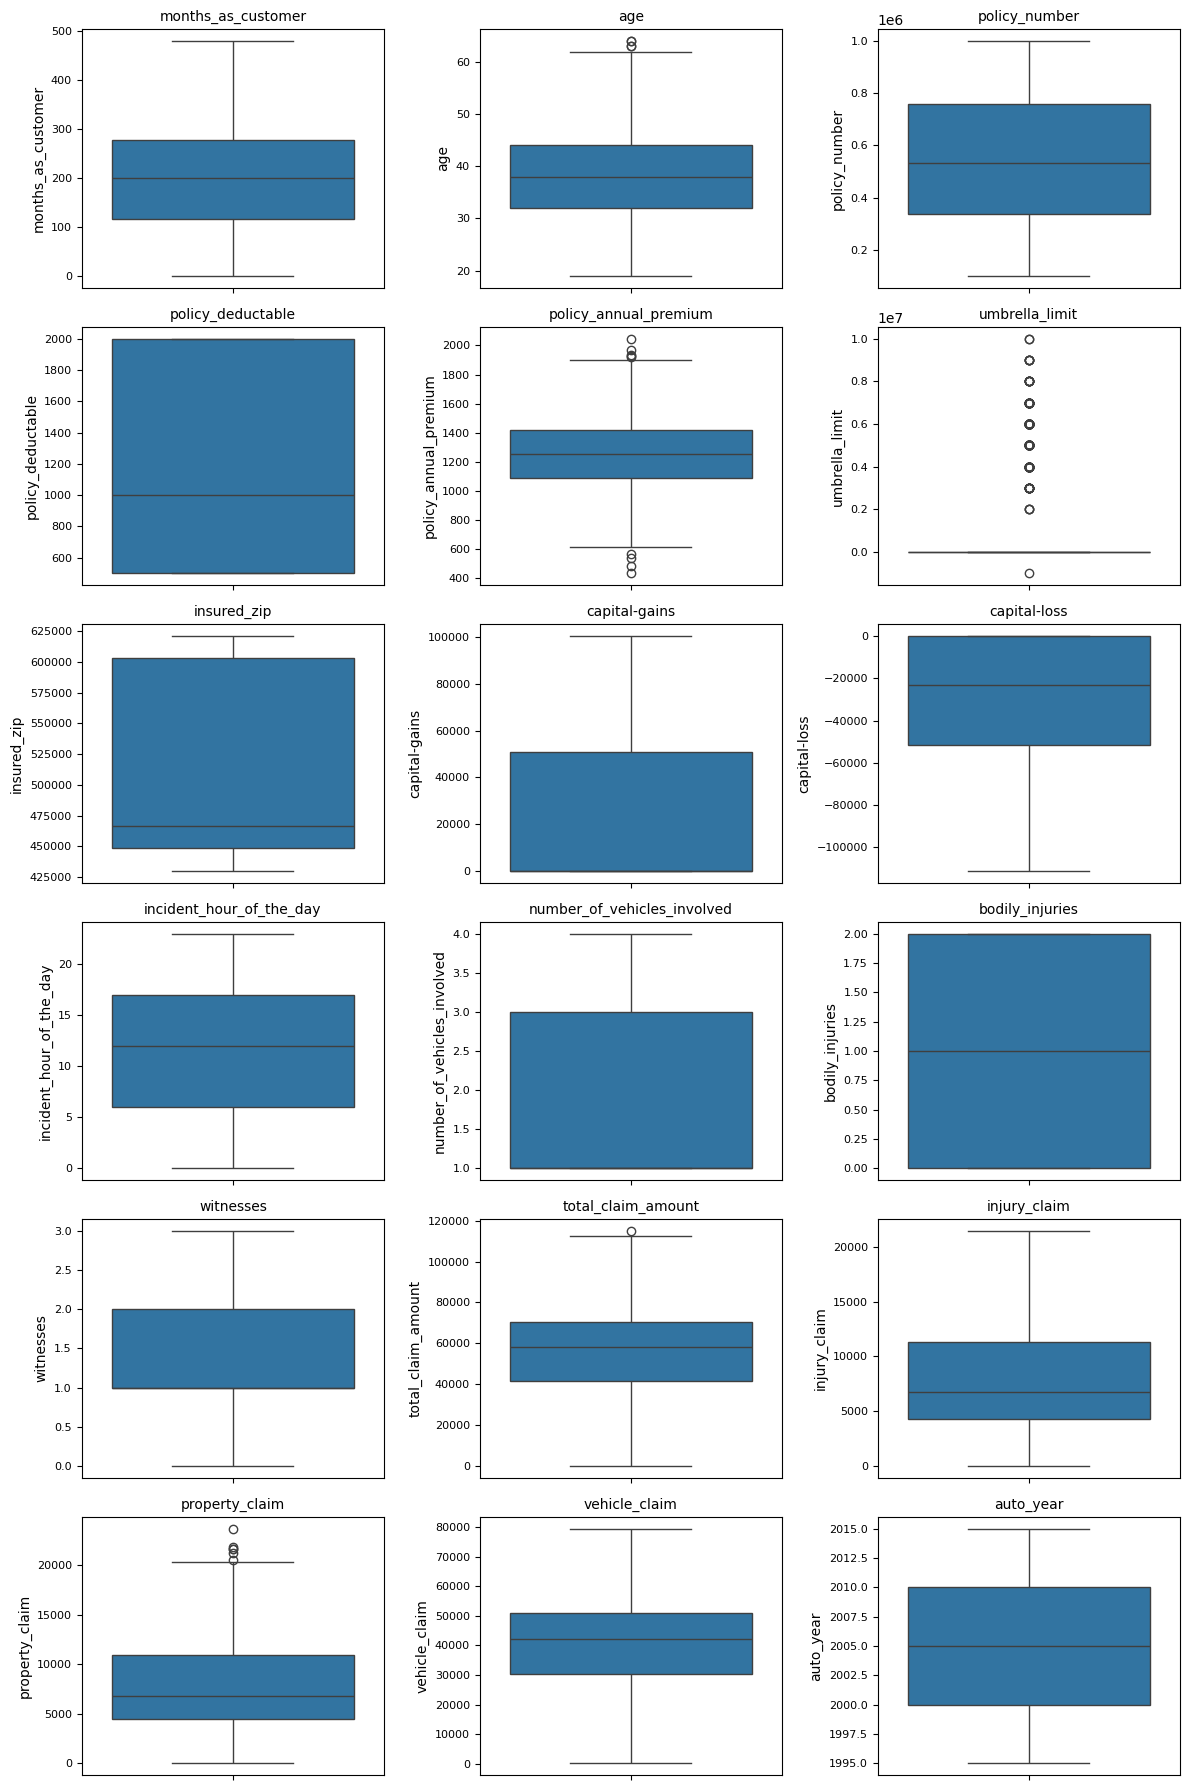

In [11]:
n_cols = 3  # how many plots per row (adjust this)
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

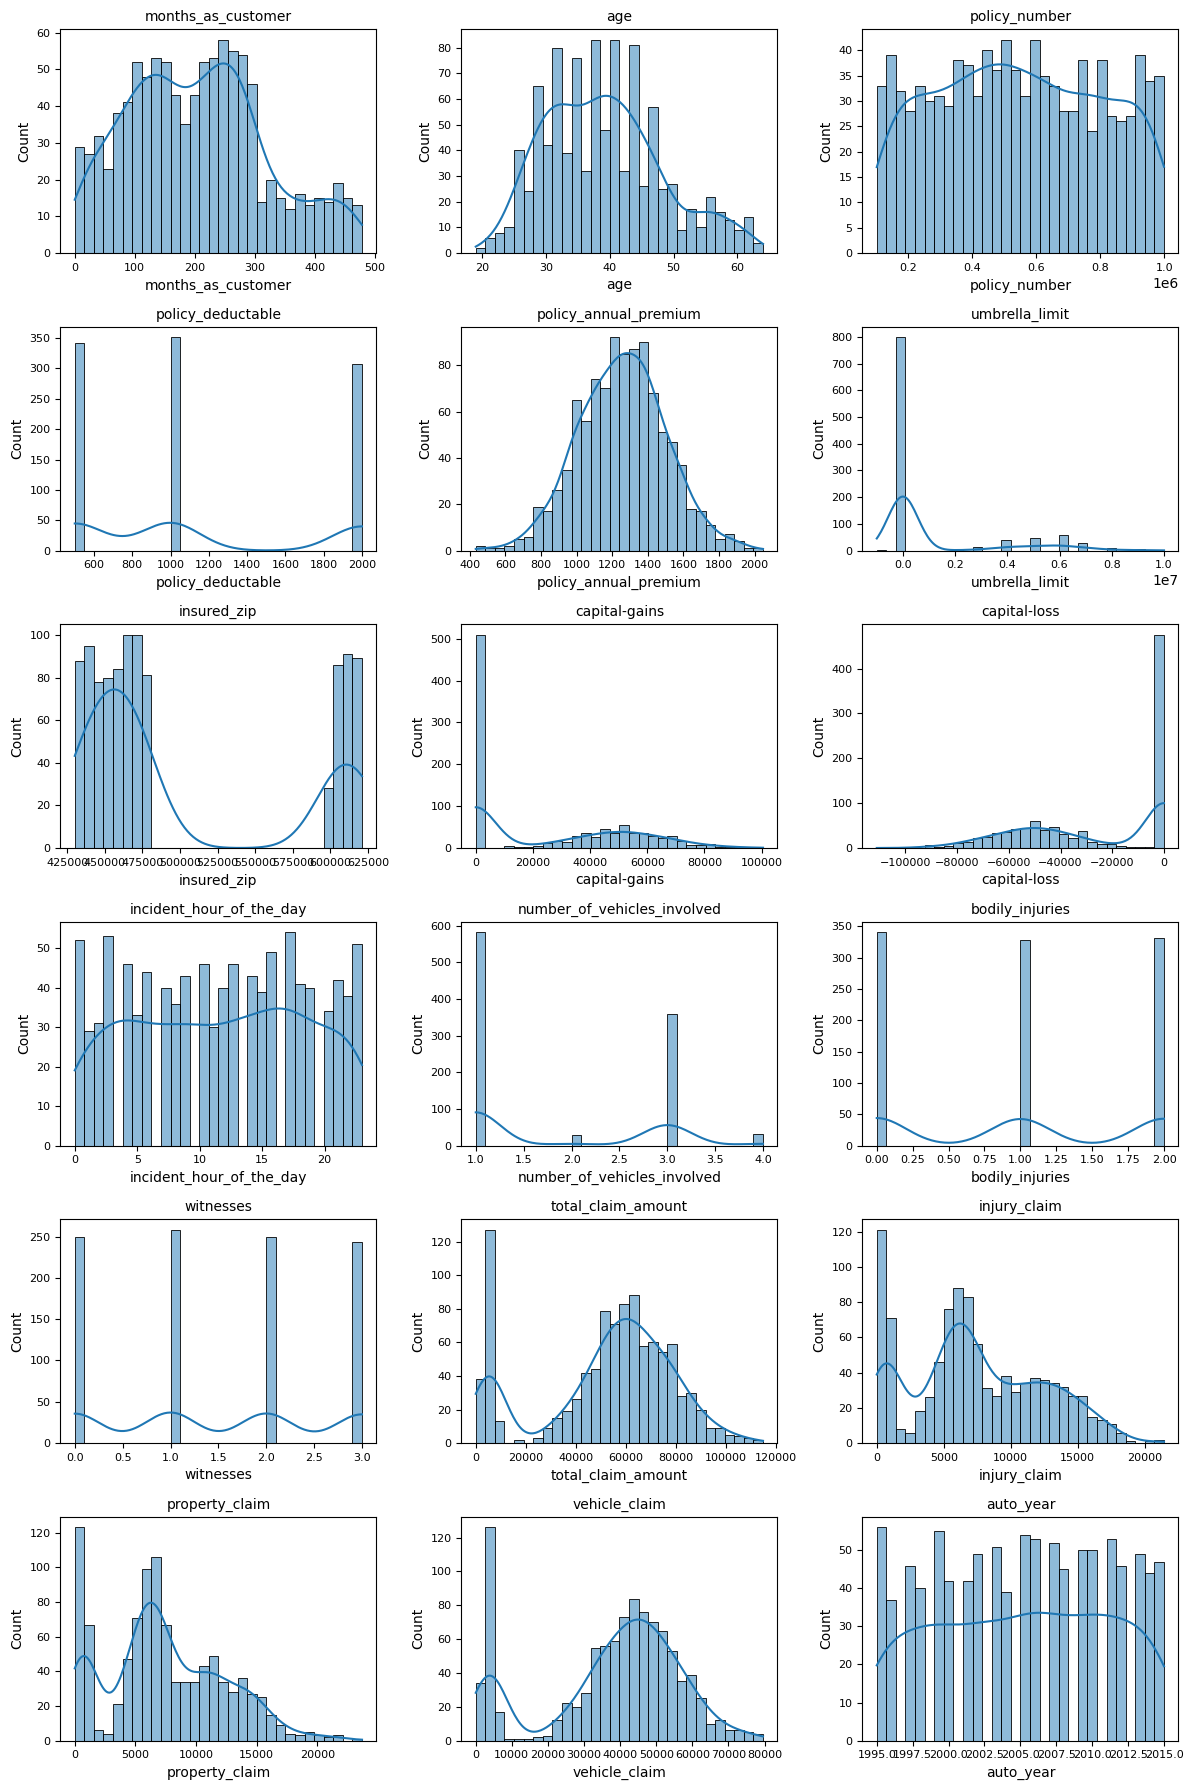

In [ ]:
# Remove fully NaN columns
num_cols = [col for col in num_cols if df[col].dropna().shape[0] > 0]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))

# Fix shape if only one row
if n_rows == 1:
    axes = np.array(axes).reshape(1, -1)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(),
                 bins=30,
                 kde=True,       # optional density curve
                 ax=axes[i])
    
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Remove empty subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Numerical - Correlation

# Categorical Variables

## Categorical - Correlation

In [4]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

In [7]:
list(df.select_dtypes(include='O').columns)

['policy_state',
 'policy_csl',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'auto_model',
 'fraud_reported']

In [10]:
df_encoded = pd.get_dummies(df, columns=list(df.select_dtypes(include='O').columns))
print(df_encoded.shape)
df_encoded.head(5)

(1000, 1167)


,months_as_customer,age,policy_number,policy_bind_date,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_date,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39,policy_state_IL,policy_state_IN,policy_state_OH,policy_csl_100/300,policy_csl_250/500,policy_csl_500/1000,insured_sex_FEMALE,insured_sex_MALE,insured_education_level_Associate,insured_education_level_College,insured_education_level_High School,insured_education_level_JD,insured_education_level_MD,insured_education_level_Masters,insured_education_level_PhD,insured_occupation_adm-clerical,insured_occupation_armed-forces,insured_occupation_craft-repair,insured_occupation_exec-managerial,insured_occupation_farming-fishing,insured_occupation_handlers-cleaners,insured_occupation_machine-op-inspct,insured_occupation_other-service,insured_occupation_priv-house-serv,insured_occupation_prof-specialty,insured_occupation_protective-serv,insured_occupation_sales,insured_occupation_tech-support,insured_occupation_transport-moving,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,insured_hobbies_dancing,insured_hobbies_exercise,insured_hobbies_golf,insured_hobbies_hiking,insured_hobbies_kayaking,insured_hobbies_movies,insured_hobbies_paintball,insured_hobbies_polo,insured_hobbies_reading,insured_hobbies_skydiving,insured_hobbies_sleeping,insured_hobbies_video-games,insured_hobbies_yachting,insured_relationship_husband,insured_relationship_not-in-family,insured_relationship_other-relative,insured_relationship_own-child,insured_relationship_unmarried,insured_relationship_wife,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,collision_type_?,collision_type_Front Collision,collision_type_Rear Collision,collision_type_Side Collision,incident_severity_Major Damage,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV,incident_city_Arlington,incident_city_Columbus,incident_city_Hillsdale,incident_city_Northbend,incident_city_Northbrook,incident_city_Riverwood,incident_city_Springfield,incident_location_1012 5th Lane,incident_location_1028 Sky Lane,incident_location_1030 Pine Lane,incident_location_1087 Flute Drive,incident_location_1091 1st Drive,incident_location_1102 Apache Hwy,incident_location_1110 4th Drive,incident_location_1123 5th Lane,incident_location_1126 Texas Hwy,incident_location_1128 Maple Lane,incident_location_1133 Apache St,incident_location_1135 Solo Lane,incident_location_1173 Andromedia Ave,incident_location_1186 Rock St,incident_location_1213 4th Lane,incident_location_1215 Pine Hwy,incident_location_1218 Sky Hwy,incident_location_1220 MLK Ave,incident_location_1229 5th Ave,incident_location_1240 Tree Lane,incident_location_1248 MLK Ridge,incident_location_1267 Francis Hwy,incident_location_1269 Flute Drive,incident_location_1273 Rock Lane,incident_location_1275 4th Ridge,incident_location_1298 Maple Hwy,incident_location_1306 Andromedia St,incident_location_1316 Britain Ridge,incident_location_1320 Flute Lane,incident_location_1325 1st Lane,incident_location_1328 Texas Lane,incident_location_1331 Britain Hwy,incident_location_1331 Elm Ridge,incident_location_1346 5th Lane,incident_location_1353 Washington St,incident_location_1358 Maple St,incident_location_1364 Best St,incident_location_1365 Francis Ave,incident_location_1371 Texas Lane,incident_location_1376 Pine St,incident_location_1381 Francis Ave,incident_location_1386

In [12]:
df_encoded.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
       'insured_zip', 'capital-gains', 'capital-loss',
       ...
       'auto_model_Pathfinder', 'auto_model_RAM', 'auto_model_RSX',
       'auto_model_Silverado', 'auto_model_TL', 'auto_model_Tahoe',
       'auto_model_Ultima', 'auto_model_Wrangler', 'auto_model_X5',
       'auto_model_X6'],
      dtype='object', length=166)

In [22]:
cat_var1_df = df_encoded.select_dtypes(include='bool').drop(columns=['fraud_reported_N','insured_sex_MALE'], axis = 1)
cat_var1 = cat_var1_df.columns
cat_var1

Index(['fraud_reported_Y', 'policy_state_IL', 'policy_state_IN',
       'policy_state_OH', 'policy_csl_100/300', 'policy_csl_250/500',
       'policy_csl_500/1000', 'insured_sex_FEMALE',
       'insured_education_level_Associate', 'insured_education_level_College',
       ...
       'auto_model_Pathfinder', 'auto_model_RAM', 'auto_model_RSX',
       'auto_model_Silverado', 'auto_model_TL', 'auto_model_Tahoe',
       'auto_model_Ultima', 'auto_model_Wrangler', 'auto_model_X5',
       'auto_model_X6'],
      dtype='object', length=141)

In [23]:
from itertools import combinations
from scipy.stats import chi2_contingency
import pandas as pd

df_cat_v1 = df_encoded[list(cat_var1)]

result = []

for var1, var2 in combinations(cat_var1, 2):
    ct = pd.crosstab(df_cat_v1[var1], df_cat_v1[var2])
    chi2, p, dof, expected = chi2_contingency(ct)
    result.append((var1, var2, p))

result


[('fraud_reported_Y', 'policy_state_IL', np.float64(0.35345697471253945)),
 ('fraud_reported_Y', 'policy_state_IN', np.float64(0.7596129472225719)),
 ('fraud_reported_Y', 'policy_state_OH', np.float64(0.5850967793876896)),
 ('fraud_reported_Y', 'policy_csl_100/300', np.float64(0.6120222544603281)),
 ('fraud_reported_Y', 'policy_csl_250/500', np.float64(0.4605822353025225)),
 ('fraud_reported_Y', 'policy_csl_500/1000', np.float64(0.16879769431670572)),
 ('fraud_reported_Y', 'insured_sex_FEMALE', np.float64(0.36665138406877407)),
 ('fraud_reported_Y',
  'insured_education_level_Associate',
  np.float64(0.7841999049232519)),
 ('fraud_reported_Y',
  'insured_education_level_College',
  np.float64(0.7595745294276954)),
 ('fraud_reported_Y',
  'insured_education_level_High School',
  np.float64(0.54582107563771)),
 ('fraud_reported_Y',
  'insured_education_level_JD',
  np.float64(0.7295327041435756)),
 ('fraud_reported_Y',
  'insured_education_level_MD',
  np.float64(0.6865807833114993)),
 (

In [24]:
df_results = pd.DataFrame(result)
df_results = df_results[df_results[0]=='fraud_reported_Y'].sort_values([2], ascending=[True])
df_results.head(10)

,0,1,2
62,fraud_reported_Y,incident_severity_Major Damage,1.595859e-58
33,fraud_reported_Y,insured_hobbies_chess,5.746682e-20
63,fraud_reported_Y,incident_severity_Minor Damage,6.198478e-14
34,fraud_reported_Y,insured_hobbies_cross-fit,1.757265e-11
64,fraud_reported_Y,incident_severity_Total Loss,9.625512e-08
58,fraud_reported_Y,collision_type_?,1.401416e-07
65,fraud_reported_Y,incident_severity_Trivial Damage,5.569816e-05
57,fraud_reported_Y,incident_type_Vehicle Theft,2.172473e-04
55,fraud_reported_Y,incident_type_Parked Car,1.205125e-03
60,fraud_reported_Y,collision_type_Rear Collision,3.042158e-03


## Categorical - Plots

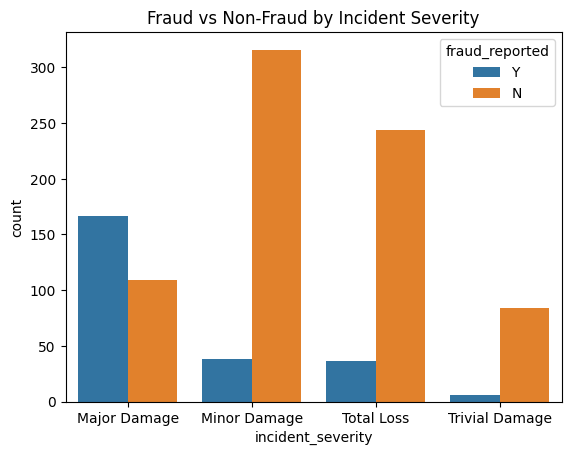

In [36]:
sns.countplot(x = 'incident_severity', hue = 'fraud_reported', data = df)
plt.title("Fraud vs Non-Fraud by Incident Severity")
plt.show()

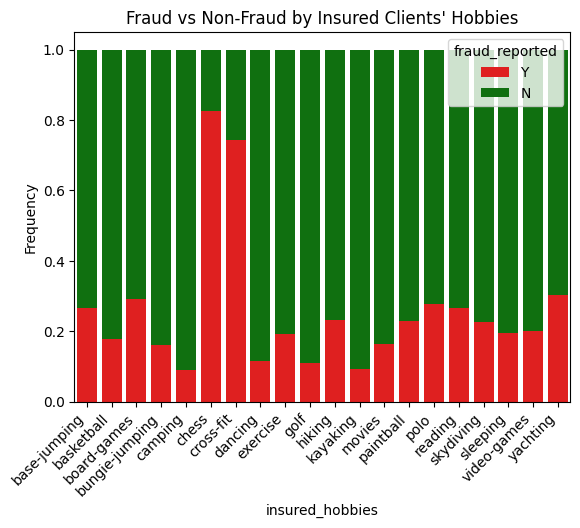

In [ ]:
ct = pd.crosstab(df['insured_hobbies'], df['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # Swaps position

ct_long = ct.reset_index().melt(id_vars='insured_hobbies',var_name='fraud_reported',value_name='count')

# Create base plot
fig, ax = plt.subplots()

# Plot Yes first
sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'Y'],
            x='insured_hobbies',y='count', color='red',label='Y',ax=ax)

# Plot No stacked on top
bottom_vals = ct['Y'].values

sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'N'], 
            x='insured_hobbies',y='count', color='green',label='N',ax=ax,bottom=bottom_vals)

plt.ylabel('Frequency')
plt.title("Fraud vs Non-Fraud by Insured Clients' Hobbies")
plt.legend(title='fraud_reported')
plt.xticks(rotation=45, ha='right')
plt.show()

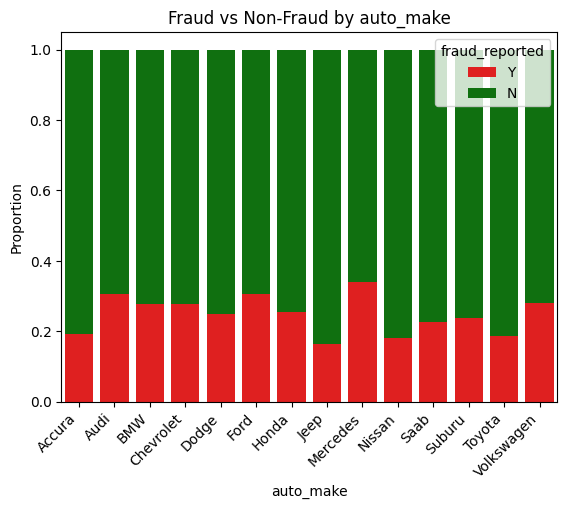

In [25]:
ct = pd.crosstab(df['auto_make'], df['fraud_reported'], normalize='index') 
ct = ct[['Y', 'N']] # Swaps position 
ct_long = ct.reset_index().melt(id_vars='auto_make',var_name='fraud_reported',value_name='count') 
# Create base plot 
fig, ax = plt.subplots() 
# Plot Yes first 
sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'Y'], x='auto_make',y='count', color='red',label='Y',ax=ax) 
# Plot No stacked on top 
bottom_vals = ct['Y'].values 
sns.barplot(data=ct_long[ct_long['fraud_reported'] == 'N'], x='auto_make',y='count', color='green',label='N',ax=ax,bottom=bottom_vals) 
plt.ylabel('Proportion') 
plt.title("Fraud vs Non-Fraud by auto_make") 
plt.legend(title='fraud_reported') 
plt.xticks(rotation=45, ha='right') 
plt.show()

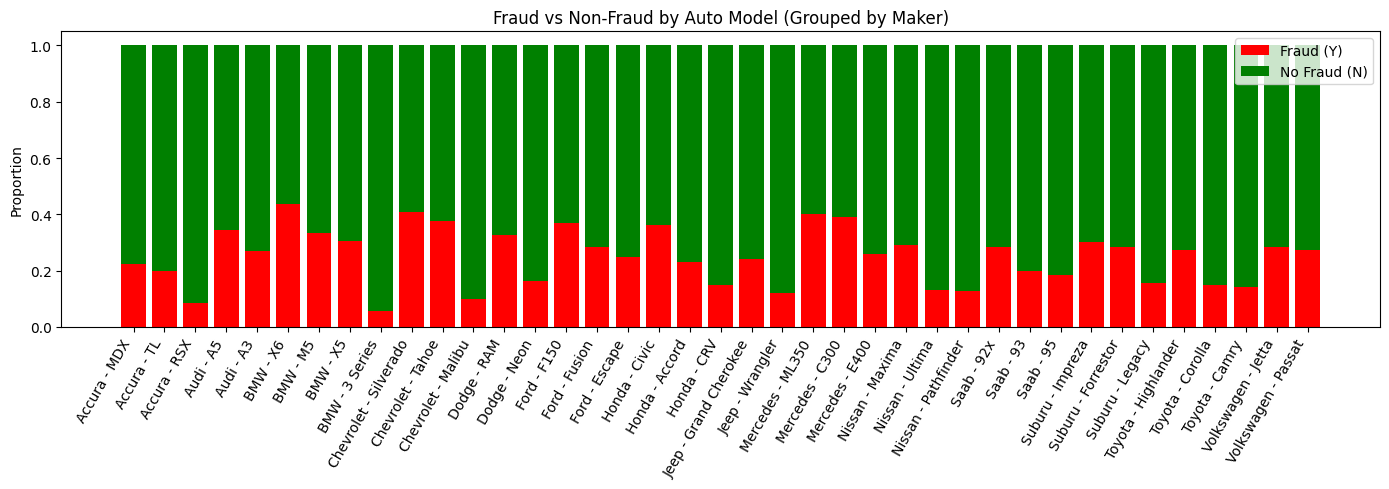

In [ ]:
# Crosstab normalized by model within maker 
ct = pd.crosstab([df['auto_make'], df['auto_model']], df['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # order Y then N

# Sort models inside each maker by fraud rate
ct = ct.sort_values(by=['auto_make', 'Y'], ascending=[True, False])

# Create labels "Maker - Model"
labels = [f"{make} - {model}" for make, model in ct.index]

# Plot stacked bars
plt.figure(figsize=(14, 5))

plt.bar(labels, ct['Y'], color='red', label='Fraud (Y)')
plt.bar(labels, ct['N'], bottom=ct['Y'], color='green', label='No Fraud (N)')

plt.ylabel("Proportion")
plt.title("Fraud vs Non-Fraud by Auto Model (Grouped by Maker)")
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

In [94]:
# Create normalized crosstab

females = df[df['insured_sex']=='FEMALE']

ct = pd.crosstab(females['auto_model'],females['fraud_reported'],normalize='index')
ct = ct[['Y', 'N']]
top5_models_female = ct.sort_values(by='Y', ascending=False).head(5)

top5_models_female_list = top5_models_female.index.tolist()
top5_models_female_df = df[df['auto_model'].isin(top5_models_female_list)]
top5_models_female

fraud_reported,Y,N
auto_model,,
X6,0.500000,0.500000
Tahoe,0.500000,0.500000
Silverado,0.500000,0.500000
Civic,0.444444,0.555556
ML350,0.444444,0.555556


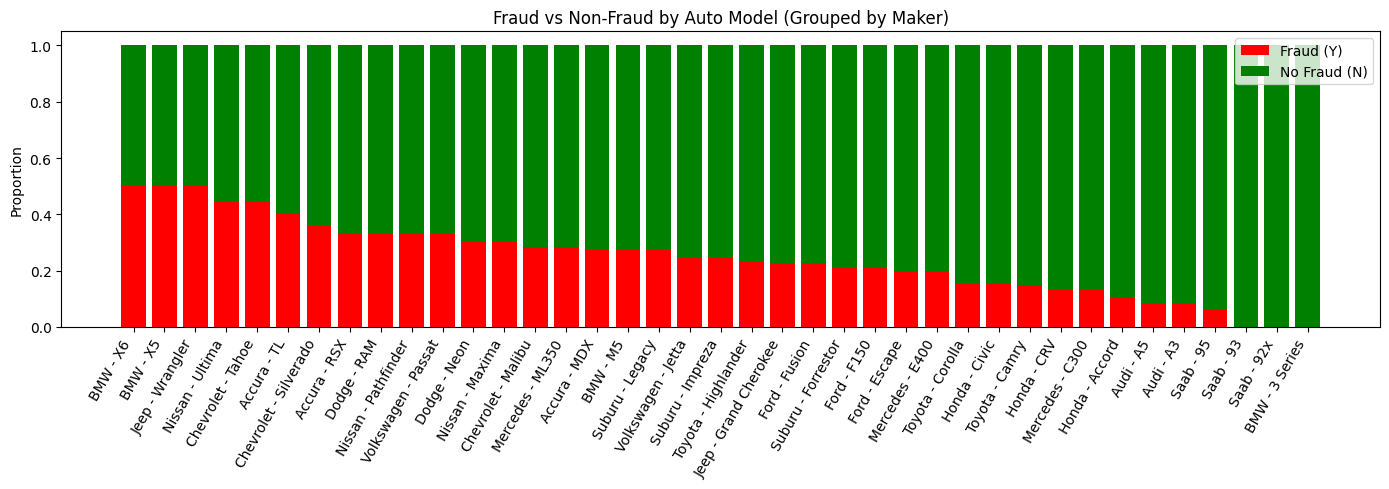

In [101]:
females = df[df['insured_sex']=='FEMALE']

# Crosstab normalized by model within maker 
ct = pd.crosstab(females['auto_model'], females['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # order Y then N

# Sort models inside each maker by fraud rate
ct = ct.sort_values(by='Y', ascending=False)

# Create labels "Maker - Model"
#labels = [f"{make} - {model}" for make, model in ct.index]

# Plot stacked bars
plt.figure(figsize=(14, 5))

plt.bar(labels, ct['Y'], color='red', label='Fraud (Y)')
plt.bar(labels, ct['N'], bottom=ct['Y'], color='green', label='No Fraud (N)')

plt.ylabel("Proportion")
plt.title("Fraud vs Non-Fraud by Auto Model (Grouped by Maker)")
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

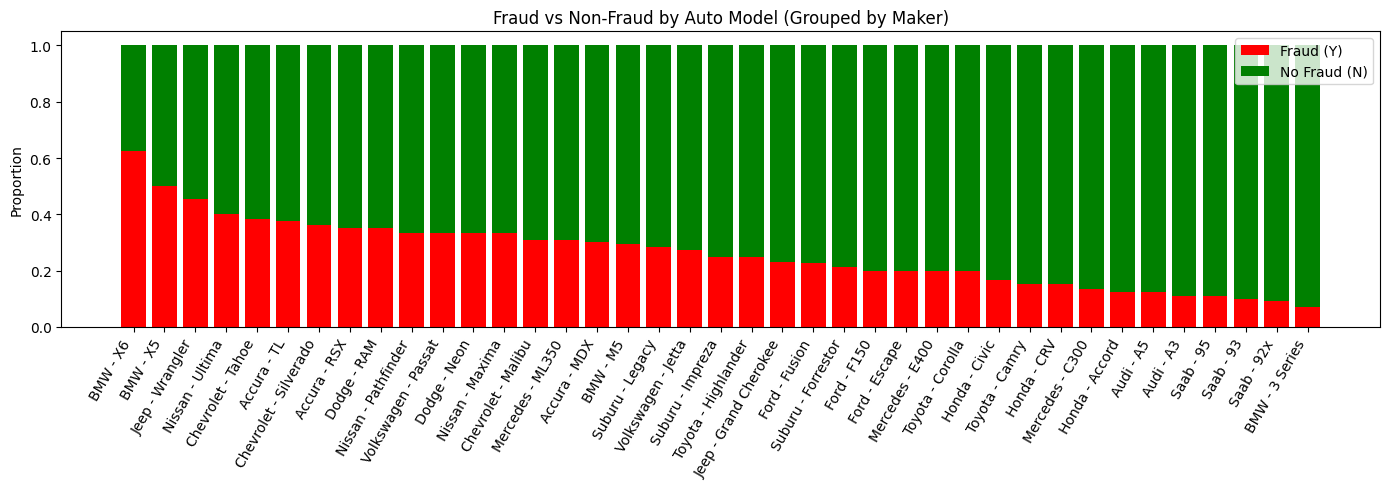

In [99]:
males = df[df['insured_sex']=='MALE']

# Crosstab normalized by model within maker 
ct = pd.crosstab(males['auto_model'], males['fraud_reported'], normalize='index')
ct = ct[['Y', 'N']]   # order Y then N

# Sort models inside each maker by fraud rate
ct = ct.sort_values(by='Y', ascending=False)

# Create labels "Maker - Model"
#labels = [f"{make} - {model}" for make, model in ct.index]

# Plot stacked bars
plt.figure(figsize=(14, 5))

plt.bar(labels, ct['Y'], color='red', label='Fraud (Y)')
plt.bar(labels, ct['N'], bottom=ct['Y'], color='green', label='No Fraud (N)')

plt.ylabel("Proportion")
plt.title("Fraud vs Non-Fraud by Auto Model (Grouped by Maker)")
plt.xticks(rotation=60, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [ ]:
# 'incident_type', 'collision_type', 'incident_severity', 
# 'authorities_contacted', 'witnesses', 'police_report_available'
# 'incident_hour_of_the_day'
# 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 
# 'total_claim_amount'
# 'injury_claim', 'property_claim', 'vehicle_claim', 
# 'auto_make', 'auto_model', 'auto_year'
# 'policy_state', 'policy_csl'
# 'policy_bind_date'
# 'insured_sex'

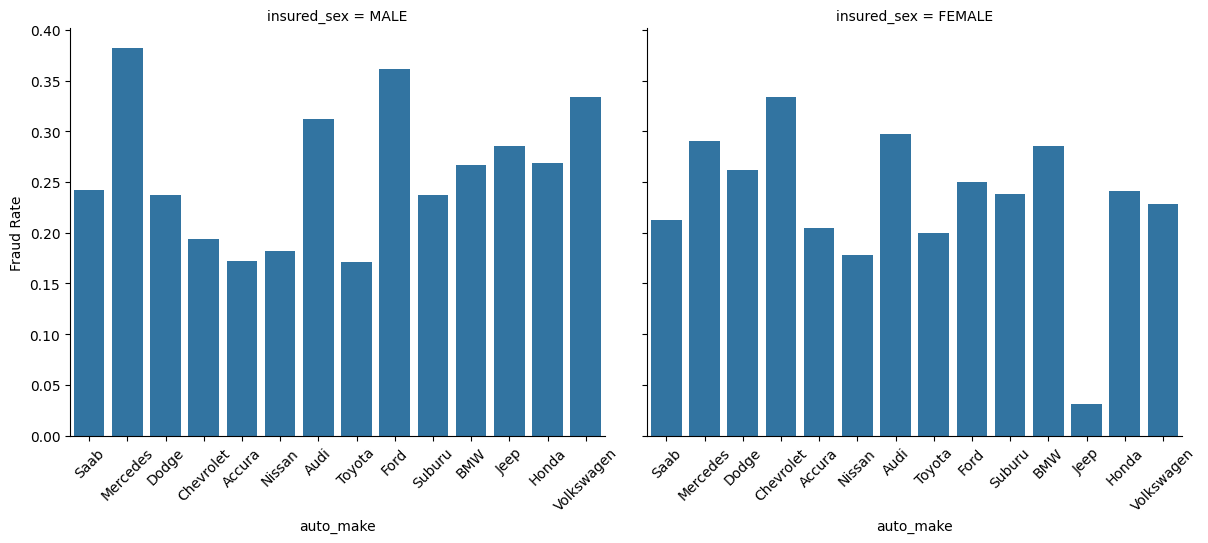

In [122]:
g = sns.catplot(
    data=df,
    x='auto_make',
    y=(df['fraud_reported'] == 'Y'),
    col='insured_sex',
    kind='bar',
    height=5,
    aspect=1.2,
    errorbar=None
)

g.set_xticklabels(rotation=45)
g.set_ylabels("Fraud Rate");

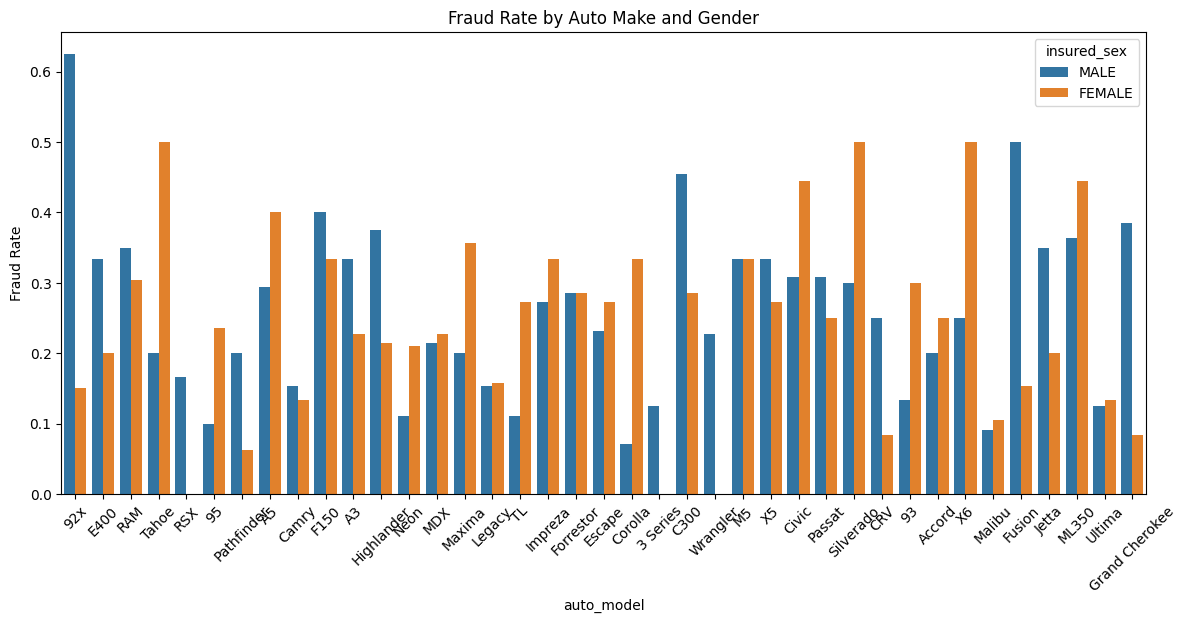

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=df,
    x='auto_model',
    y=(df['fraud_reported'] == 'Y'),
    hue='insured_sex',
    errorbar=None
)

plt.title("Fraud Rate by Auto Make and Gender")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

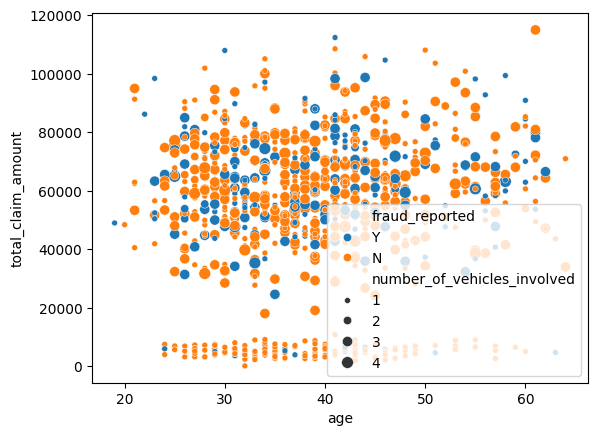

In [126]:
sns.scatterplot(
    data=df,
    x='age',
    y='total_claim_amount',
    hue='fraud_reported',
    size='number_of_vehicles_involved'
);

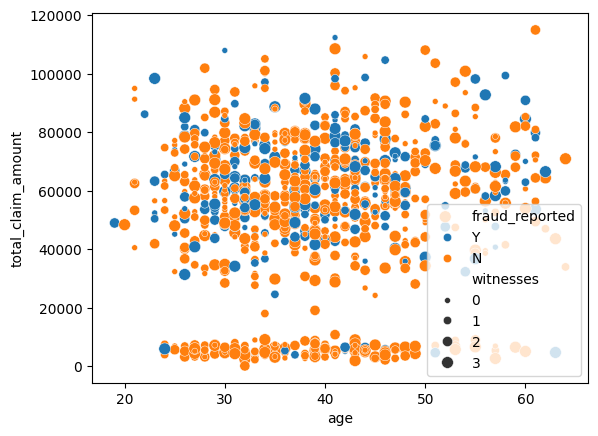

In [132]:
sns.scatterplot(
    data=df,
    x='age',
    y='total_claim_amount',
    hue='fraud_reported',
    size='witnesses'
);

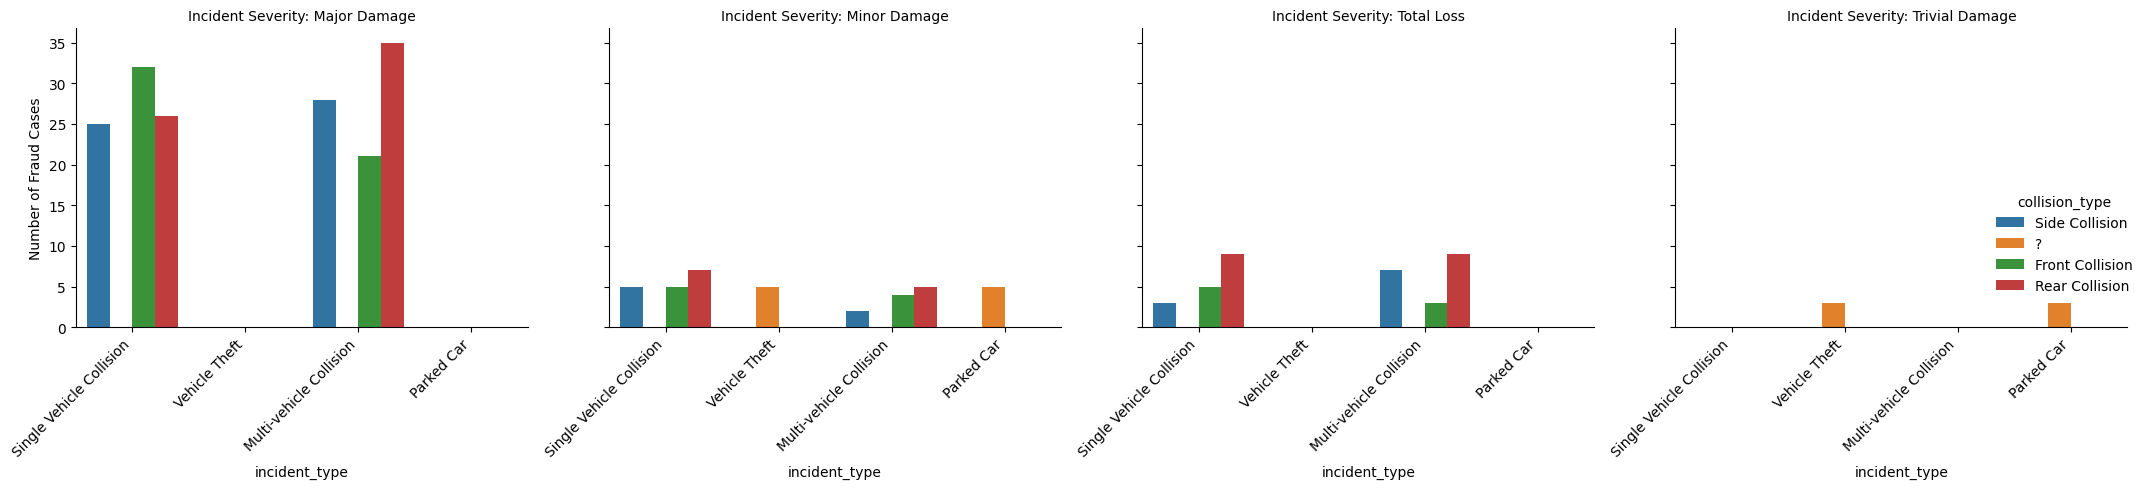

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only fraud cases
g = sns.catplot(
    data=df[df['fraud_reported']=='Y'],
    x='incident_type',
    hue='collision_type',
    col='incident_severity',
    kind='count',
    height=5,
    aspect=1
)

# Rotate x-axis labels for all facets
g.set_xticklabels(rotation=45, horizontalalignment='right')

# Set y-labels and titles
g.set_ylabels("Number of Fraud Cases")
g.set_titles("Incident Severity: {col_name}")

plt.tight_layout()
plt.show()

In [140]:
frauds = df[df['fraud_reported']=='Y']
f = frauds[frauds['incident_severity']=='Trivial Damage']
f

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
196,196,36,602410,1996-01-16,IN,250/500,2000,1463.07,0,615611,MALE,MD,armed-forces,skydiving,own-child,0,0,2015-01-24,Vehicle Theft,?,Trivial Damage,Police,WV,Springfield,4939 Best St,3,1,?,1,1,NO,5300,530,530,4240,Jeep,Grand Cherokee,2001,Y,NaN
281,186,33,779075,2010-02-27,IN,100/300,1000,1348.32,0,469429,FEMALE,Associate,craft-repair,cross-fit,wife,37600,-37600,2015-01-14,Vehicle Theft,?,Trivial Damage,Police,NY,Arlington,8477 Francis Hwy,3,1,NO,2,1,?,4730,860,860,3010,Chevrolet,Malibu,2013,Y,NaN
437,255,44,903203,2004-01-03,OH,500/1000,2000,814.96,6000000,435267,FEMALE,PhD,priv-house-serv,chess,not-in-family,68500,0,2015-02-05,Parked Car,?,Trivial Damage,Police,NC,Hillsdale,2787 MLK St,7,1,?,2,2,NO,6400,640,1280,4480,Mercedes,ML350,2005,Y,NaN
597,3,29,276804,1992-11-27,IL,100/300,500,995.70,5000000,615446,FEMALE,JD,priv-house-serv,chess,unmarried,0,0,2015-02-02,Parked Car,?,Trivial Damage,Police,PA,Springfield,1821 Andromedia Ridge,3,1,?,2,1,?,5000,500,1000,3500,Mercedes,E400,2008,Y,NaN
635,140,35,155912,2008-03-21,OH,100/300,1000,1520.78,0,470538,FEMALE,High School,craft-repair,chess,wife,0,-42900,2015-01-21,Parked Car,?,Trivial Damage,NaN,SC,Columbus,3320 5th Hwy,5,1,?,0,2,YES,2860,520,260,2080,Chevrolet,Tahoe,1997,Y,NaN
837,9,24,326180,2002-05-25,IL,100/300,2000,1304.46,0,473349,FEMALE,PhD,machine-op-inspct,golf,other-relative,51700,-33300,2015-01-31,Vehicle Theft,?,Trivial Damage,NaN,NC,Arlington,6939 3rd Hwy,6,1,NO,0,3,YES,5940,540,1080,4320,Audi,A5,2001,Y,NaN


In [137]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

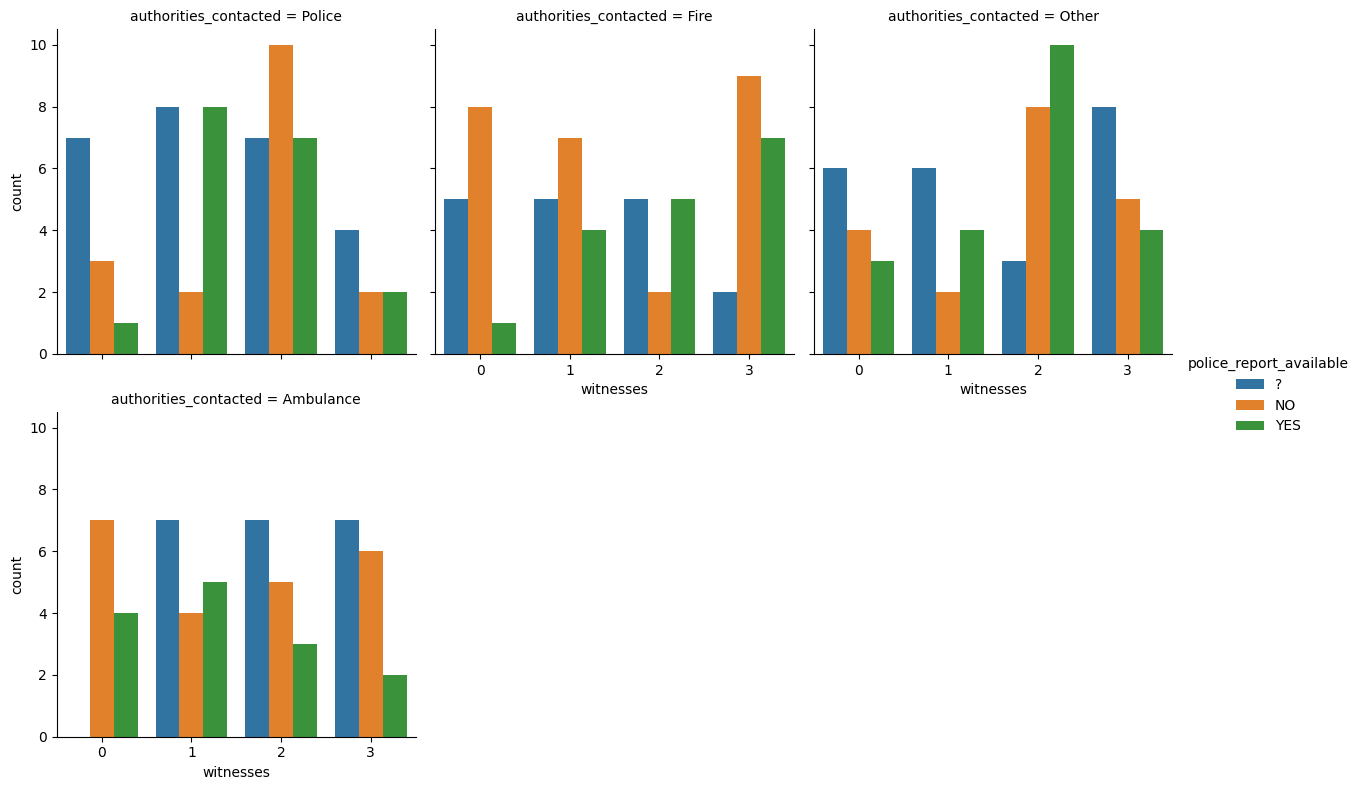

In [117]:
sns.catplot(
    data=df[df['fraud_reported']=='Y'],  # only fraud cases
    x='witnesses',
    hue='police_report_available',
    col='authorities_contacted',
    kind='count',
    col_wrap=3,
    height=4,
    aspect=1
)

plt.xticks(rotation=0)
plt.show()